In [ ]:
!pip install transformers accelerate torch numpy matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5/295.5 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 MB 6.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.7/267.7 MB 9.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 157.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 142.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [9]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from google.colab import userdata

print("Loading OLMoE-1B-7B-0125-Instruct...")
model_name = "allenai/OLMoE-1B-7B-0125-Instruct"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="cuda"
)
print("Model loaded!")

Loading OLMoE-1B-7B-0125-Instruct...


In [14]:
model.get_memory_footprint()

13838324224

In [4]:
!nvidia-smi

Fri Apr 10 20:08:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             52W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [25]:
print("\n" + "="*60)
print("MODEL OVERVIEW")
print("="*60)

total_params = 0
linear_params = 0
layer_info = []

for name, param in model.named_parameters():
    total_params += param.numel()
    if 'weight' in name and len(param.shape) == 2:  # Linear layers
        linear_params += param.numel()
        layer_info.append({
            'name': name,
            'shape': tuple(param.shape),
            'params': param.numel(),
            'size_mb_fp16': param.numel() * 2 / 1e6
        })

print(f"Total parameters:  {total_params:,}")
print(f"Linear layer params: {linear_params:,} ({100*linear_params/total_params:.1f}%)")
# print(f"\nFP16 size:  {total_params * 2 / 1e9:.2f} GB")
# print(f"2-bit size: {linear_params * 0.25 / 1e9:.2f} GB (linear layers only)")
print(f"Compression ratio: {16/2:.0f}x for linear layers")

print(f"\nNumber of linear layers to quantize: {len(layer_info)}")
print(f"\nFirst 20 linear layers:")
for info in layer_info[:20]:
    print(f"  {info['name']:50s} shape={str(info['shape']):20s} "
          f"params={info['params']:>10,}  ({info['size_mb_fp16']:.1f} MB)")


MODEL OVERVIEW
Total parameters:  476,710,912
Linear layer params: 476,577,792 (100.0%)
Compression ratio: 8x for linear layers

Number of linear layers to quantize: 82

First 20 linear layers:
  model.embed_tokens.weight                          shape=(50304, 2048)        params=103,022,592  (206.0 MB)
  model.layers.0.self_attn.q_proj.weight             shape=(2048, 2048)         params= 4,194,304  (8.4 MB)
  model.layers.0.self_attn.k_proj.weight             shape=(2048, 2048)         params= 4,194,304  (8.4 MB)
  model.layers.0.self_attn.v_proj.weight             shape=(2048, 2048)         params= 4,194,304  (8.4 MB)
  model.layers.0.self_attn.o_proj.weight             shape=(2048, 2048)         params= 4,194,304  (8.4 MB)
  model.layers.0.mlp.gate.weight                     shape=(64, 2048)           params=   131,072  (0.3 MB)
  model.layers.1.self_attn.q_proj.weight             shape=(2048, 2048)         params= 4,194,304  (8.4 MB)
  model.layers.1.self_attn.k_proj.weight      

In [6]:
import pandas as pd
import torch

skip = {'q_norm', 'k_norm', 'layernorm', 'rotary', 'norm'}

rows = []
with torch.no_grad():
    for name, param in model.named_parameters():
        if param.ndim >= 2 and not any(s in name.lower() for s in skip):
            w = param.detach().float()
            w_abs = w.abs()
            std = w.std().item()
            rows.append({
                'layer': name,
                'shape': tuple(w.shape),
                'numel': w.numel(),
                'max': w_abs.max().item(),
                'mean': w_abs.mean().item(),
                'std': std,
                'outlier_score': (w_abs.max() / w_abs.mean()).item(),
                'outlier_pct': (w_abs > 3*std).float().mean().item() * 100,
                'kurtosis': ((w - w.mean())**4).mean().item() / (w.var().item()**2 + 1e-12),
            })
df = pd.DataFrame(rows)
df

,layer,shape,numel,max,mean,std,outlier_score,outlier_pct,kurtosis
0,model.embed_tokens.weight,"(50304, 2048)",103022592,0.225586,0.007325,0.009436,30.797567,0.581026,3.568867
1,model.layers.0.self_attn.q_proj.weight,"(2048, 2048)",4194304,0.225586,0.002470,0.006661,91.343330,3.025460,33.091503
2,model.layers.0.self_attn.k_proj.weight,"(2048, 2048)",4194304,0.247070,0.002320,0.006267,106.476357,3.104448,29.074811
3,model.layers.0.self_attn.v_proj.weight,"(2048, 2048)",4194304,0.145508,0.007415,0.010493,19.624577,1.661038,6.778985
4,model.layers.0.self_attn.o_proj.weight,"(2048, 2048)",4194304,0.328125,0.004956,0.008020,66.204536,1.840734,30.950768
...,...,...,...,...,...,...,...,...,...
109,model.layers.15.self_attn.o_proj.weight,"(2048, 2048)",4194304,0.859375,0.014422,0.019059,59.587463,0.467205,91.392608
110,model.layers.15.mlp.gate.weight,"(64, 2048)",131072,0.302734,0.010284,0.014894,29.437254,1.136017,23.294110
111,model.layers.15.mlp.experts.gate_up_proj,"(64, 2048, 2048)",268435456,0.804688,0.014431,0.018253,55.759762,0.409388,3.421319
112,model.layers.15.mlp.experts.down_proj,"(64, 2048, 1024)",134217728,1.343750,0.013489,0.017083,99.617210,0.385468,6.164046


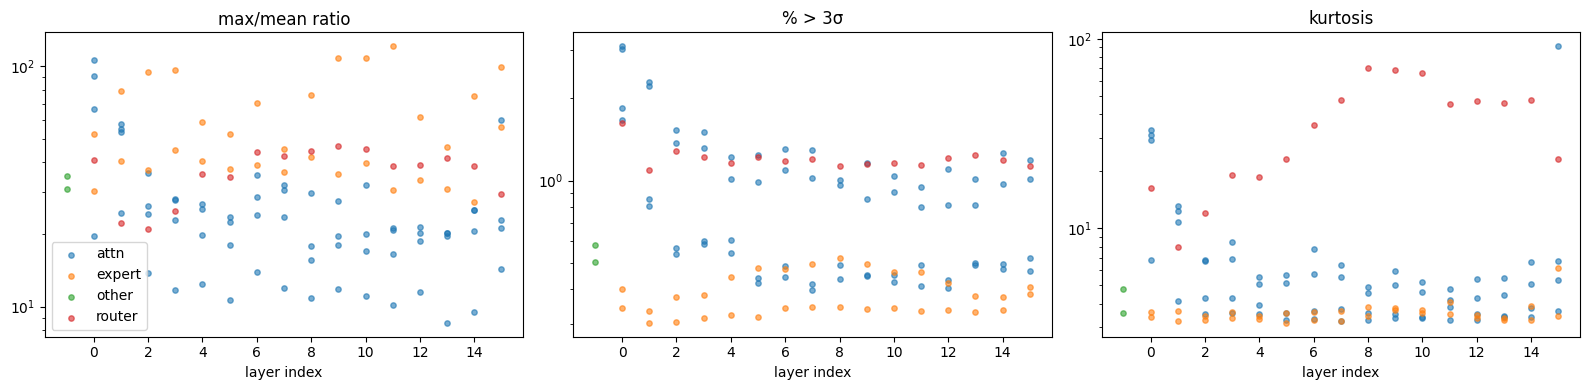

In [6]:
import matplotlib.pyplot as plt
import re

# Extract layer index and component type from param name
def parse(name):
    m = re.search(r'layers?\.(\d+)', name)
    idx = int(m.group(1)) if m else -1
    if 'expert' in name: comp = 'expert'
    elif 'attn' in name or 'q_proj' in name or 'k_proj' in name or 'v_proj' in name or 'o_proj' in name: comp = 'attn'
    elif 'router' in name or 'gate' in name: comp = 'router'
    else: comp = 'other'
    return idx, comp

df[['layer_idx', 'component']] = df['layer'].apply(lambda x: pd.Series(parse(x)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for comp, sub in df.groupby('component'):
    axes[0].scatter(sub['layer_idx'], sub['outlier_score'], label=comp, alpha=0.6, s=15)
    axes[1].scatter(sub['layer_idx'], sub['outlier_pct'], label=comp, alpha=0.6, s=15)
    axes[2].scatter(sub['layer_idx'], sub['kurtosis'], label=comp, alpha=0.6, s=15)
for ax, title in zip(axes, ['max/mean ratio', '% > 3σ', 'kurtosis']):
    ax.set_xlabel('layer index'); ax.set_title(title); ax.set_yscale('log')
axes[0].legend()
plt.tight_layout()

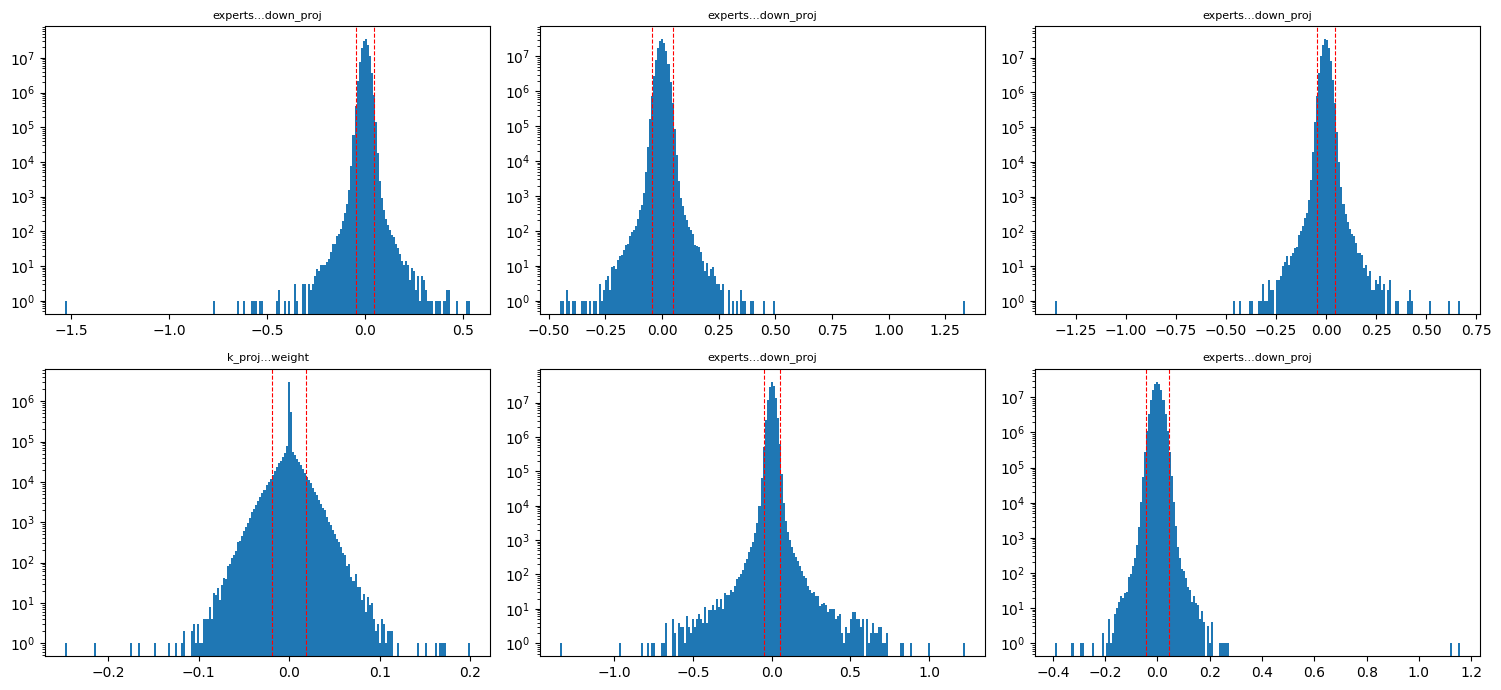

In [7]:
worst = df.nlargest(6, 'outlier_score')
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (_, row) in zip(axes.flat, worst.iterrows()):
    w = dict(model.named_parameters())[row['layer']].detach().float().flatten().cpu().numpy()
    ax.hist(w, bins=200, log=True)
    ax.axvline(3*row['std'], color='r', ls='--', lw=0.8)
    ax.axvline(-3*row['std'], color='r', ls='--', lw=0.8)
    ax.set_title(row['layer'].split('.')[-2] + '...' + row['layer'].split('.')[-1], fontsize=8)
plt.tight_layout()

In [8]:
expert_rows = []
with torch.no_grad():
    for name, param in model.named_parameters():
        if 'experts' in name and param.ndim == 3:
            # param shape: [num_experts, dim_a, dim_b]
            w = param.detach().float()
            layer_idx = int(re.search(r'layers\.(\d+)', name).group(1))
            proj = name.split('.')[-1]  # e.g. 'gate_up_proj' or 'down_proj'
            num_experts = w.shape[0]
            for e in range(num_experts):
                we = w[e]
                we_abs = we.abs()
                std = we.std().item()
                expert_rows.append({
                    'layer_idx': layer_idx,
                    'expert_idx': e,
                    'proj': proj,
                    'outlier_score': (we_abs.max() / we_abs.mean()).item(),
                    'outlier_pct': (we_abs > 3*std).float().mean().item() * 100,
                    'kurtosis': ((we - we.mean())**4).mean().item() / (we.var().item()**2 + 1e-12),
                })
expert_df = pd.DataFrame(expert_rows)

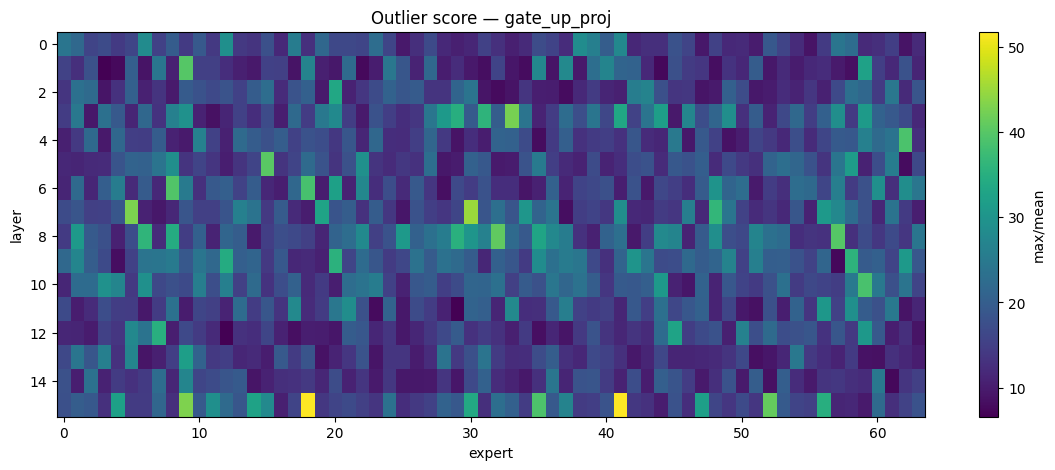

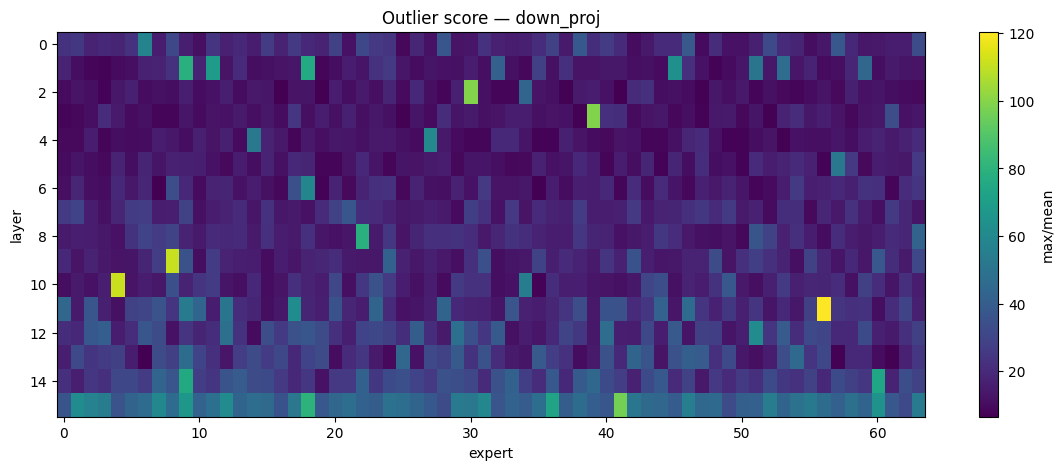

In [36]:
for proj in expert_df['proj'].unique():
    sub = expert_df[expert_df['proj'] == proj]
    pivot = sub.pivot_table(index='layer_idx', columns='expert_idx',
                            values='outlier_score', aggfunc='max')
    plt.figure(figsize=(14, 5))
    plt.imshow(pivot.values, aspect='auto', cmap='viridis')
    plt.colorbar(label='max/mean')
    plt.xlabel('expert'); plt.ylabel('layer')
    plt.title(f'Outlier score — {proj}')
    plt.show()

In [15]:
from torch import nn
import torch.nn.functional as F
from transformers.activations import ACT2FN
from transformers.models.olmoe.configuration_olmoe import OlmoeConfig
from transformers.models.olmoe.modeling_olmoe import OlmoeExperts

class W8A16OlmoeExperts(nn.Module):
    def __init__(self, config: OlmoeConfig):
        super().__init__()
        self.num_experts = config.num_local_experts
        self.hidden_dim = config.hidden_size
        self.intermediate_dim = config.intermediate_size
        self.act_fn = ACT2FN[config.hidden_act]

        # 3D int8 weight buffers
        self.register_buffer("int8_gate_up_proj",
            torch.zeros(self.num_experts, 2 * self.intermediate_dim, self.hidden_dim, dtype=torch.int8))
        self.register_buffer("int8_down_proj",
            torch.zeros(self.num_experts, self.hidden_dim, self.intermediate_dim, dtype=torch.int8))

        # Scales: one per output row, per expert  →  (num_experts, out_features)
        self.register_buffer("scales_gate_up_proj",
            torch.zeros(self.num_experts, 2 * self.intermediate_dim))
        self.register_buffer("scales_down_proj",
            torch.zeros(self.num_experts, self.hidden_dim))

    @staticmethod
    def _quantize_3d(weights: torch.Tensor):
        """weights: (num_experts, out, in)  →  int8 weights + scales"""
        w_fp32 = weights.float()
        # max over the in_features dim → shape (num_experts, out_features)
        scales = w_fp32.abs().max(dim=-1).values / 127
        int8_w = torch.round(w_fp32 / scales.unsqueeze(-1)).to(torch.int8)
        return int8_w, scales.to(weights.dtype)

    def quantize(self, gate_up_proj: torch.Tensor, down_proj: torch.Tensor):
        self.int8_gate_up_proj, self.scales_gate_up_proj = self._quantize_3d(gate_up_proj)
        self.int8_down_proj, self.scales_down_proj = self._quantize_3d(down_proj)


    @staticmethod
    def _dequant_linear(x: torch.Tensor, int8_w: torch.Tensor, scales: torch.Tensor):
        # Matmul in fp first, then apply per-row scales to the output
        casted = int8_w.to(x.dtype)
        out = F.linear(x, casted)
        return out * scales  # scales shape (out_features,) broadcasts over batch

    def forward(self, hidden_states, top_k_index, top_k_weights):
        final_hidden_states = torch.zeros_like(hidden_states)
        with torch.no_grad():
            expert_mask = nn.functional.one_hot(top_k_index, num_classes=self.num_experts)
            expert_mask = expert_mask.permute(2, 1, 0)
            expert_hit = expert_mask.sum(dim=(-1, -2)).gt(0).nonzero()

        for expert_idx in expert_hit:
            expert_idx = expert_idx[0]
            top_k_pos, token_idx = torch.where(expert_mask[expert_idx])
            current_state = hidden_states[token_idx]

            # gate_up with dequantized weights for this expert
            gate, up = self._dequant_linear(
                current_state,
                self.int8_gate_up_proj[expert_idx],   # (2*intermediate, hidden)
                self.scales_gate_up_proj[expert_idx],  # (2*intermediate,)
            ).chunk(2, dim=-1)

            current_hidden_states = self.act_fn(gate) * up

            current_hidden_states = self._dequant_linear(
                current_hidden_states,
                self.int8_down_proj[expert_idx],       # (hidden, intermediate)
                self.scales_down_proj[expert_idx],     # (hidden,)
            )

            current_hidden_states *= top_k_weights[token_idx, top_k_pos, None]
            final_hidden_states.index_add_(0, token_idx,
                                           current_hidden_states.to(final_hidden_states.dtype))

        return final_hidden_states


In [16]:
def quantize_olmoe_experts_(model: nn.Module):
    """Replace all OlmoeExperts with W8A16OlmoeExperts in-place."""
    for name, module in model.named_children():
        if isinstance(module, OlmoeExperts):
            q = W8A16OlmoeExperts(module.config)  # assumes config is stored on module
            q.quantize(module.gate_up_proj.data, module.down_proj.data)
            setattr(model, name, q)
        else:
            quantize_olmoe_experts_(module)  # recurse

In [17]:
quantize_olmoe_experts_(model=model)
model.get_memory_footprint()/1e+9

7.404261888

In [6]:
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

Allocated: 5.85 GB
Reserved:  5.85 GB


In [21]:
import torch
import json
from transformers import AutoTokenizer

device = torch.device("cuda:0")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model.eval()

text = "OLMoE-1B-7B-0125-Instruct January 2025 is post-trained variant of the OLMoE-1B-7B January 2025 model, which has undergone "
inputs = tokenizer(text, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}   # ← move inputs to GPU

with torch.no_grad():
    output = model.generate(**inputs)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

print(f"Tokens: {tokens}")
print(tokenizer.decode(output[0][inputs["input_ids"].shape[-1]:]))
# print(tokenizer.decode(output[0][inputs["input_ids"].shape[-1]:]))

Tokens: ['OL', 'Mo', 'E', '-', '1', 'B', '-', '7', 'B', '-', '0125', '-', 'In', 'struct', 'ĠJanuary', 'Ġ20', '25', 'Ġis', 'Ġpost', '-', 'trained', 'Ġvariant', 'Ġof', 'Ġthe', 'ĠOL', 'Mo', 'E', '-', '1', 'B', '-', '7', 'B', 'ĠJanuary', 'Ġ20', '25', 'Ġmodel', ',', 'Ġwhich', 'Ġhas', 'Ġundergone', 'Ġ']
𝛽-update (Equation 1) using the validation set performance. The specific values of
